# Module 1

Identify the top 1% outliers: adopt at least three different methods from
different families (i.e., density-based, angle-based…) and compare the
results. Visualize the outliers in a 2 or 3d scatter plot using at least one
dimensionality reduction technique. Deal with the outliers in a way you see fit, e.g. by removing them from the
dataset or by treating the anomalous variables as missing values and
employing replacement techniques. In this second case, you should check
that the outliers are not outliers anymore. Justify your choices in every
step.

## LOF (pymod)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.lof import LOF
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

df = pd.read_csv("../../processed_data/cmi_preprocessed.csv", index_col='id')


In [2]:
features_to_keep = ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-Height", "Physical-HeartRate", "BIA-BIA_BMI", "BIA-BIA_DEE", "BIA-BIA_FFMI", "BIA-BIA_FMI", "Physical-Mean_arterial_pressure", "PAQ_Combined"]
X = df[features_to_keep].values
scl = StandardScaler()
X = scl.fit_transform(X)
clf = LOF(contamination=0.012)
clf.fit(X)

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.012
,n_jobs,1
,novelty,True


In [3]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8176,   83]))

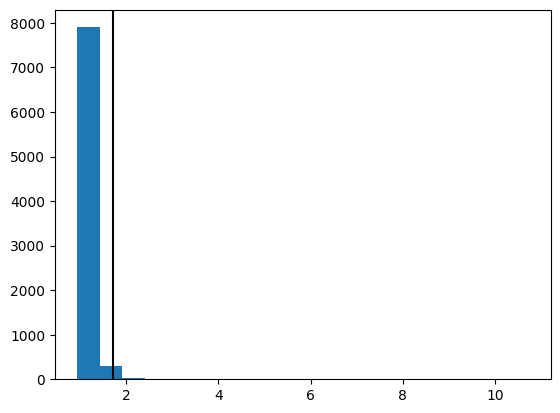

In [4]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers==1)]), c='k')
plt.show()

In [5]:
df_scores = df[features_to_keep].copy()
df_scores["lof_score"] = clf.decision_scores_
df_scores["is_outlier"] = outliers
df_scores.sort_values("lof_score", ascending=False).head(20)

,Basic_Demos-Age,CGAS-CGAS_Score,Physical-Height,Physical-HeartRate,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFMI,BIA-BIA_FMI,Physical-Mean_arterial_pressure,PAQ_Combined,lof_score,is_outlier
id,,,,,,,,,,,,
5448,10.0,71.500000,152.323800,68.000000,18.078301,124728.000000,14.142175,4.886692,76.166667,2.000000,10.720322,1
6273,16.0,49.000000,177.342800,87.500000,20.548077,124728.000000,17.574909,16.920504,119.666667,2.666667,9.485808,1
5615,13.0,55.500000,166.954200,70.500000,21.561823,80961.750842,15.292535,4.830934,80.666667,2.500000,7.828742,1
6763,12.0,77.500000,173.786800,73.500000,22.855530,59538.220877,16.836549,8.647894,74.166667,2.000000,6.490196,1
5221,14.0,62.500000,159.334200,98.500000,20.112471,53363.540487,16.283357,4.891628,77.166667,2.548333,6.228139,1
6495,16.0,61.500000,165.633400,66.000000,20.808940,52977.596444,18.784844,5.557475,85.055556,2.500000,6.156931,1
4837,9.0,65.500000,147.015200,85.000000,18.449369,21359.081945,14.913777,6.701111,80.500000,3.000000,4.828839,1
6075,17.0,65.500000,165.150800,83.500000,20.493351,37807.045961,15.454980,2.796771,128.833333,2.936667,4.591910,1
6010,5.0,59.000000,143.103600,86.500000,19.271938,46031.027969,16.325077,23.272336,80.000000,2.475000,4.150921,1


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA (3 components for both 2D and 3D plots)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 25.66%, PC2: 7.18%
Cumulative (2 PCs): 32.84%


In [7]:
outlier_mask = outliers == 1
n_outliers = outlier_mask.sum()

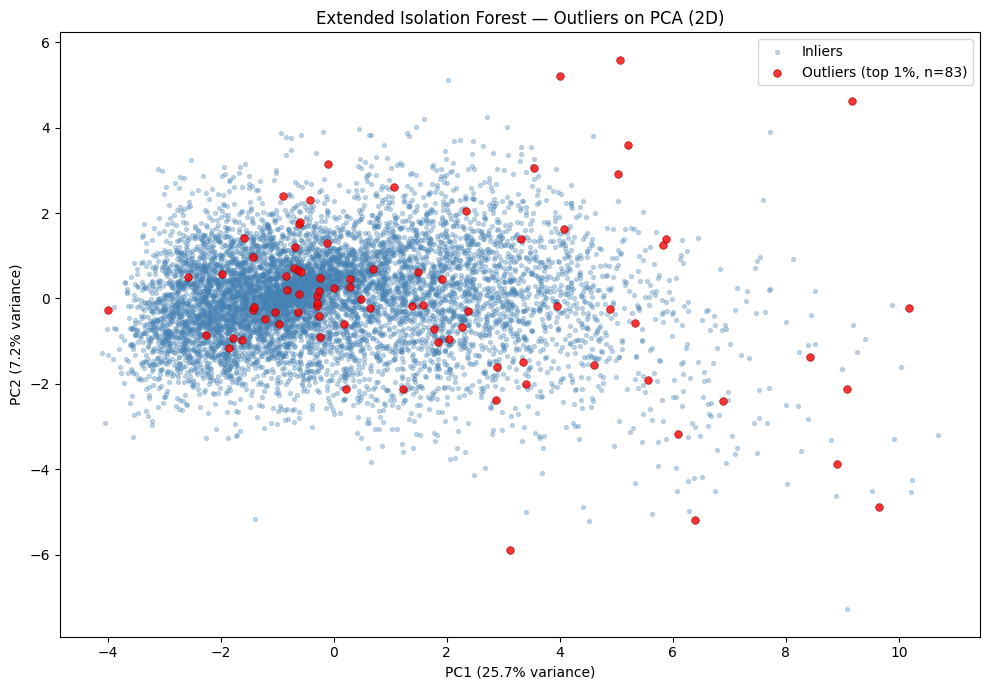

In [8]:
# 2D scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("Extended Isolation Forest — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
top_outliers = df_scores.sort_values("lof_score", ascending=False).head(10)
print(top_outliers)
df_scores.to_csv('../../outlier_data/lof.csv')

      Basic_Demos-Age  CGAS-CGAS_Score  Physical-Height  Physical-HeartRate  \
id                                                                            
5448             10.0             71.5         152.3238                68.0   
6273             16.0             49.0         177.3428                87.5   
5615             13.0             55.5         166.9542                70.5   
6763             12.0             77.5         173.7868                73.5   
5221             14.0             62.5         159.3342                98.5   
6495             16.0             61.5         165.6334                66.0   
4837              9.0             65.5         147.0152                85.0   
6075             17.0             65.5         165.1508                83.5   
6010              5.0             59.0         143.1036                86.5   
4602             17.0             58.0         178.3588                84.0   

      BIA-BIA_BMI    BIA-BIA_DEE  BIA-BIA_FFMI  BIA